<a href="https://colab.research.google.com/github/XavierMojica/Portfolio/blob/main/abtesting_binomal_chi2test_fisherexacttest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from numpy import percentile
import matplotlib.pyplot as plt
from pylab import rcParams
rcParams['figure.figsize'] = 15, 5
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
from scipy.stats import shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.graphics.factorplots import interaction_plot

In [ ]:
from google.colab import files
import pandas as pd

#uploading csv file from local to colab to then be read down below
uploaded = files.upload()

Saving ab_data.csv to ab_data.csv


In [ ]:
#Reading in data
data = pd.read_csv('ab_data.csv')

#looking at the first 5 rows
data.head()

#seeing classes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
#scaling down converted from int64 to int16 to help with computing
data['converted'] = data['converted'].astype('int16')

#changing timestamp from object to datetime type
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [ ]:
#cheking data again to see if converted was changed to int16
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int16         
dtypes: datetime64[ns](1), int16(1), int64(1), object(2)
memory usage: 9.5+ MB


In [ ]:
#checking for duplicates
duplis = data.duplicated()
print(duplis.any())

False


In [ ]:
# Count total duplicate rows
data.duplicated().sum()

# Count duplicated user_id rows
data['user_id'].duplicated().sum()

np.int64(3894)

In [ ]:
#visualize duplicates for user_id
# Show rows where user_id appears more than once
duplicates = data[data['user_id'].duplicated(keep=False)]

duplicates.sort_values('user_id').head(20)

,user_id,timestamp,group,landing_page,converted
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
11792,630137,2017-01-22 14:59:22.051308,control,new_page,0
183371,630137,2017-01-20 02:08:49.893878,control,old_page,0
255753,630320,2017-01-12 05:27:37.181803,treatment,old_page,0
207211,630320,2017-01-07 18:02:43.626318,control,old_page,0
110634,630471,2017-01-23 01:42:51.501851,control,old_page,0
96929,630471,2017-01-07 02:14:17.405726,control,new_page,0


We can see that there are mismatches between groups of treatment and control with pages new and old. Treatment should have new page and control should have old page.

In [ ]:
mismatch= data[(data['group'] == 'treatment') & (data['landing_page'] =='old_page') |
               (data['group'] == 'control') & (data['landing_page']=='new_page')]
mismatchNum = mismatch.shape[0]
print(f'Number of mismatches: {mismatchNum} rows or %.2f%%'% (mismatchNum/data.shape[0]*100))


Number of mismatches: 3893 rows or 1.32%


In [ ]:
data2 = data[(data['group'] == 'treatment') & (data['landing_page'] == 'new_page') |
             (data['group'] == 'control') & (data['landing_page'] == 'old_page')]

#drop duplicats from new df
#data2 = data2.drop_duplicates(subset = 'user_id', inplace = True)
data2.drop_duplicates(subset='user_id', inplace=True)


In [ ]:
#inspecting rows again
data2.shape

(290584, 5)

In [ ]:
df_counts = pd.DataFrame({"Control_COUNT": data2[data2.group=="control"].converted.value_counts(),
              "Treatment_COUNT": data2[data2.group=="treatment"].converted.value_counts(),
              "Control_RATIO": data2[data2.group=="control"].converted.value_counts()/ len(data2[data2.group=="control"]),
              "Treatment_RATIO": data2[data2.group=="treatment"].converted.value_counts() / len(data2[data2.group=="treatment"])})
df_counts

,Control_COUNT,Treatment_COUNT,Control_RATIO,Treatment_RATIO
converted,,,,
0,127785,128046,0.879614,0.881192
1,17489,17264,0.120386,0.118808


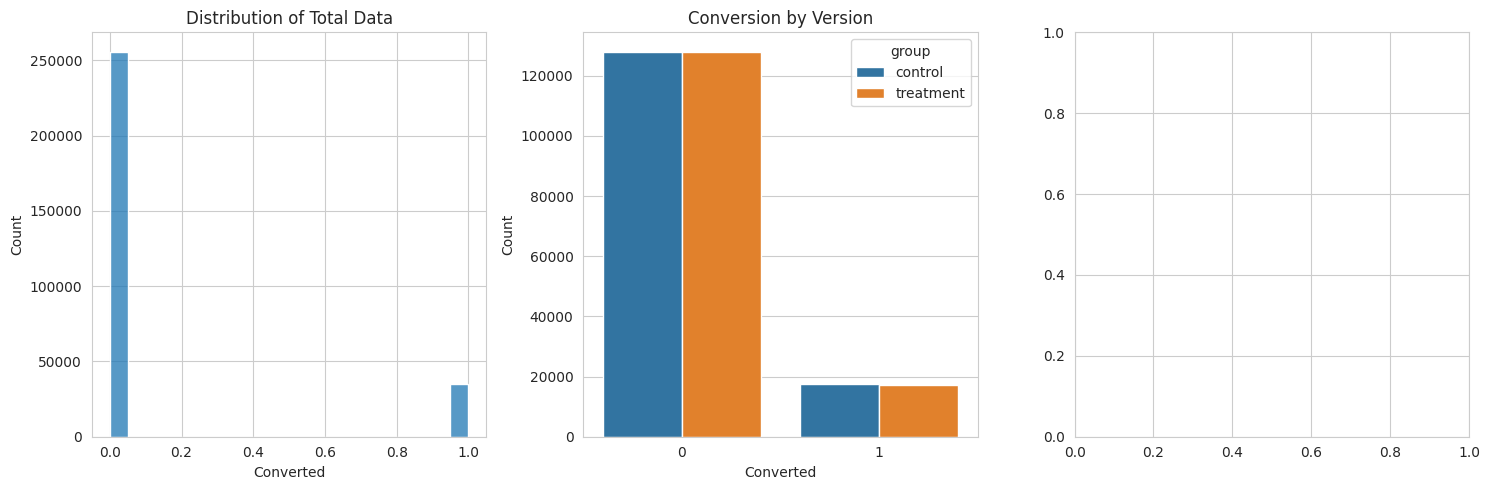

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(x='converted', data=data2, ax=axes[0])
axes[0].set_title("Distribution of Total Data")
axes[0].set_xlabel("Converted")
axes[0].set_ylabel("Count")

sns.countplot(x='converted', hue='group', data=data2, ax=axes[1])
axes[1].set_title("Conversion by Version")
axes[1].set_xlabel("Converted")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
table = df_counts.iloc[:, 0:2].to_numpy()
table

array([[127785, 128046],
       [ 17489,  17264]])

In [ ]:
#Since data are binomial/categorical aka Yes No we use Chi Square Test and seems to have Large Sample Size

# chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)
print("Degrees of Freedom=%d"% dof)
print(expected)
# interpret test-statistic
prob = 0.95
critical = stats.chi2.ppf(prob, dof)
print('Probability=%.3f, Critical=%.3f, Stat=%.3f' % (prob, critical, stat))
if abs(stat) >= critical:
    print('Dependent (reject H0)')
else:
    print('Independent (Fail to Reject H0)')
# interpret p-value
alpha = 1-prob
print('Significance=%.3f, p=%.3f' % (alpha, p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (fail to reject H0)')

Degrees of Freedom=1
[[127899.65274757 127931.34725243]
 [ 17374.34725243  17378.65274757]]
Probability=0.950, Critical=3.841, Stat=1.704
Independent (Fail to Reject H0)
Significance=0.050, p=0.192
Independent (fail to reject H0)


Alt Test to Chi Square Tset if we are unsure if we have Large enough Samples

In [ ]:
#Alt to Chi Square test is Fisher's Exact Test if we are not sure if we have Large Sample Size
odd_ratio, p_value = stats.fisher_exact(table, alternative = "two-sided")
print("Odd Ratio:", odd_ratio)
print("p-value:", p_value)

if p_value <= alpha:
  print('Dependent (reject H0)')
else:
  print('Independent (fail to reject H0)')

Odd Ratio: 0.9851226640350362
p-value: 0.19047706765708894
Independent (fail to reject H0)


A/B Test

In [ ]:
def AB_testing(dataFrame, group, metric):
    size = dataFrame.shape[0]

    # Create contingency table
    table = pd.crosstab(dataFrame[metric], dataFrame[group])

    if size < 1000:
        odds_ratio, p_value = stats.fisher_exact(table, alternative="two-sided")
        test_name = "Fisher Exact Test"
    else:
        stat, p_value, dof, expected = stats.chi2_contingency(table)
        test_name = "Chi-Square Test"

    result = pd.DataFrame({
        "Test": [test_name],
        "P_value": [p_value],
        "AB Hypothesis": ["Reject H0" if p_value < 0.05 else "Fail to Reject H0"],
        "Comment": [
            "A/B groups are not similar!" if p_value < 0.05
            else "A/B groups are similar!"
        ]
    })

    return result

In [ ]:
AB_testing(dataFrame=data2, group='group', metric='converted')

,Test,P_value,AB Hypothesis,Comment
0,Chi-Square Test,0.191822,Fail to Reject H0,A/B groups are similar!


In [2]:
!git config --global user.name "XavierMojica"
!git config --global user.email "xavier.mojica806@gmail.com"

In [3]:
!git clone https://github.com/XavierMojica/Portfolio.git

Cloning into 'Portfolio'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 59 (delta 15), reused 32 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 17.59 KiB | 8.80 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [8]:
%pwd
%ls

DataScience-Classical/  WilcoxonRankSumTestExample.R
